# Análisis Exploratorio de Datos - E-Commerce Analytics

## 1. Contexto del proyecto

Este notebook tiene como objetivo analizar el comportamiento comercial de un e-commerce utilizando datos almacenados en Snowflake.

El análisis se centra en métricas clave de negocio como ingresos, volumen de pedidos, ticket medio, comportamiento de clientes, rendimiento de productos, cancelaciones, churn y estacionalidad.

Este proyecto simula un escenario real de Analytics Engineering, donde los datos ya se encuentran modelados en un Data Warehouse y son consumidos con Python para análisis exploratorio y generación de insights.

In [97]:
# Importación de librerías

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine
from urllib.parse import quote_plus

plt.style.use("default")

## 2. Conexión con Snowflake

Las credenciales de acceso se almacenan en un archivo `.env`, lo que permite separar la configuración sensible del código fuente.

Esta práctica es importante porque evita exponer contraseñas o datos sensibles en el repositorio de GitHub.

In [98]:
# Cargar variables de entorno

load_dotenv()

sf_user = os.getenv("SF_USER")
sf_password = quote_plus(os.getenv("SF_PASSWORD"))
sf_account = os.getenv("SF_ACCOUNT")
sf_database = os.getenv("SF_DATABASE")
sf_schema = os.getenv("SF_SCHEMA")
sf_warehouse = os.getenv("SF_WAREHOUSE")

engine = create_engine(
    f"snowflake://{sf_user}:{sf_password}@{sf_account}/"
    f"{sf_database}/{sf_schema}"
    f"?warehouse={sf_warehouse}"
)

print("Conexión configurada correctamente")

Conexión configurada correctamente


In [99]:
# Validar conexión

df_test = pd.read_sql(
    "SELECT CURRENT_USER(), CURRENT_DATABASE(), CURRENT_SCHEMA()",
    engine
)

df_test

,CURRENT_USER(),CURRENT_DATABASE(),CURRENT_SCHEMA()
0,AIRFLOW,ECOMMERCE_BD,PUBLIC


## 3. Carga de datos

En esta sección se cargan las tablas principales desde Snowflake hacia DataFrames de Pandas.

In [100]:
query_orders = "SELECT * FROM FCT_ORDERS"
query_items = "SELECT * FROM FCT_ORDER_ITEMS"
query_customers = "SELECT * FROM DIM_CUSTOMERS"
query_products = "SELECT * FROM DIM_PRODUCTS"
query_customer_metrics = "SELECT * FROM CUSTOMERS_METRICS"
query_daily_sales = "SELECT * FROM DAILY_SALES"
query_cancel_metrics = "SELECT * FROM CANCEL_METRICS"
query_cancellations = "SELECT * FROM CANCELAMENTOS"

df_orders = pd.read_sql(query_orders, engine)
df_items = pd.read_sql(query_items, engine)
df_customers = pd.read_sql(query_customers, engine)
df_products = pd.read_sql(query_products, engine)
df_customer_metrics = pd.read_sql(query_customer_metrics, engine)
df_daily_sales = pd.read_sql(query_daily_sales, engine)
df_cancel_metrics = pd.read_sql(query_cancel_metrics, engine)
df_cancellations = pd.read_sql(query_cancellations, engine)

In [101]:
# Normalización de nombres de columnas

dataframes = [
    df_orders,
    df_items,
    df_customers,
    df_products,
    df_customer_metrics,
    df_daily_sales,
    df_cancel_metrics,
    df_cancellations
]

for df in dataframes:
    df.columns = df.columns.str.upper()

In [102]:
# Conversión de columnas de fecha

df_orders["ORDER_DATE"] = pd.to_datetime(df_orders["ORDER_DATE"])
df_items["ORDER_DATE"] = pd.to_datetime(df_items["ORDER_DATE"])
df_daily_sales["ORDER_DATE"] = pd.to_datetime(df_daily_sales["ORDER_DATE"])

df_customer_metrics["FIRST_PURCHASE_DATE"] = pd.to_datetime(df_customer_metrics["FIRST_PURCHASE_DATE"])
df_customer_metrics["LAST_PURCHASE_DATE"] = pd.to_datetime(df_customer_metrics["LAST_PURCHASE_DATE"])

df_cancel_metrics["ORDER_DATE"] = pd.to_datetime(df_cancel_metrics["ORDER_DATE"])

df_cancellations["cancel_date"] = pd.to_datetime(df_cancellations["cancel_date"])

print("Datos cargados y fechas convertidas correctamente")

Datos cargados y fechas convertidas correctamente


## 4. Resumen inicial de los datasets

Antes de avanzar con el análisis, se revisa el tamaño de cada tabla.

In [103]:
datasets = {
    "Pedidos": df_orders,
    "Items de pedidos": df_items,
    "Clientes": df_customers,
    "Productos": df_products,
    "Métricas de clientes": df_customer_metrics,
    "Ventas diarias": df_daily_sales,
    "Métricas de cancelaciones": df_cancel_metrics,
    "Cancelaciones": df_cancellations
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} filas y {df.shape[1]} columnas")

Pedidos: 1000 filas y 8 columnas
Items de pedidos: 2557 filas y 13 columnas
Clientes: 500 filas y 4 columnas
Productos: 100 filas y 5 columnas
Métricas de clientes: 430 filas y 11 columnas
Ventas diarias: 326 filas y 5 columnas
Métricas de cancelaciones: 133 filas y 5 columnas
Cancelaciones: 171 filas y 3 columnas


## 5. Análisis de ingresos y volumen de pedidos

### Pregunta de negocio

¿Cuál es la evolución de los ingresos y del volumen de pedidos a lo largo del tiempo?

In [104]:
revenue_monthly = (
    df_orders
    .groupby(df_orders["ORDER_DATE"].dt.to_period("M"))
    .agg(
        TOTAL_REVENUE=("TOTAL_REVENUE", "sum"),
        TOTAL_ORDERS=("ORDER_ID", "nunique")
    )
    .reset_index()
)

revenue_monthly["ORDER_DATE"] = revenue_monthly["ORDER_DATE"].astype(str)

revenue_monthly

,ORDER_DATE,TOTAL_REVENUE,TOTAL_ORDERS
0,2025-04,33447.08,74
1,2025-05,40581.10,91
2,2025-06,29408.96,65
3,2025-07,35467.73,80
4,2025-08,43213.18,88
5,2025-09,39860.67,78
6,2025-10,44880.40,96
7,2025-11,41267.36,84
8,2025-12,38880.98,82
9,2026-01,41493.14,87


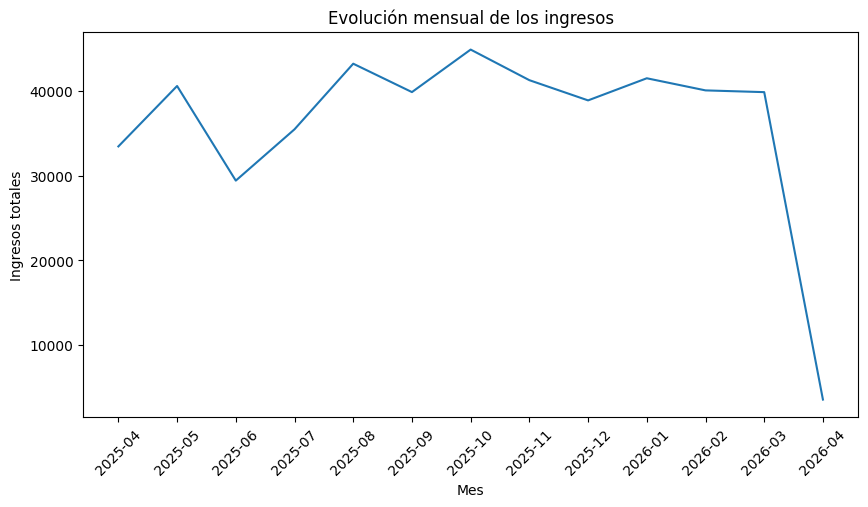

In [105]:
plt.figure(figsize=(10, 5))
plt.plot(revenue_monthly["ORDER_DATE"], revenue_monthly["TOTAL_REVENUE"])
plt.title("Evolución mensual de los ingresos")
plt.xlabel("Mes")
plt.ylabel("Ingresos totales")
plt.xticks(rotation=45)
plt.show()

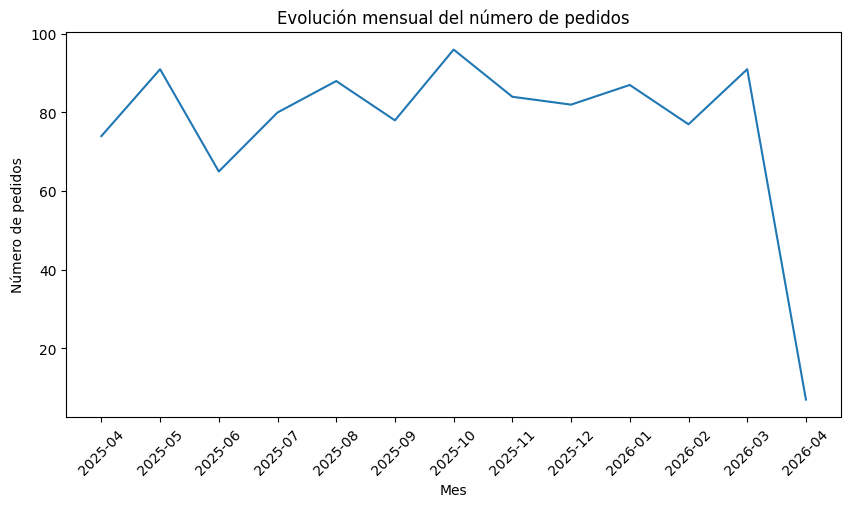

In [106]:
plt.figure(figsize=(10, 5))
plt.plot(revenue_monthly["ORDER_DATE"], revenue_monthly["TOTAL_ORDERS"])
plt.title("Evolución mensual del número de pedidos")
plt.xlabel("Mes")
plt.ylabel("Número de pedidos")
plt.xticks(rotation=45)
plt.show()

### Interpretación

Esta sección permite identificar si el negocio está creciendo, si existen caídas puntuales en ventas o si hay meses con mayor concentración de pedidos.La caída de abril de 2026 es esperada, no es alarmante. Con solo 7 pedidos y 3.559 € de ingresos hasta ahora este mes (frente a la media de ~87 pedidos / 40K €), está claro que es un mes parcial - conviene añadir una nota en el notebook para evitar que reclutadores o revisores lo interpreten como un problema del negocio.

Tendencias que destacan en tus datos:

Los ingresos y el volumen de pedidos están muy correlacionados - el valor medio por pedido se mantiene estable alrededor de 450–470 €, lo cual es una señal positiva.

Se observa una ligera caída - diciembre de 2025 fue el mes completo más bajo de la segunda mitad del año (38,9K €, 82 pedidos), con recuperación entre enero y marzo de 2026.

Junio de 2025 fue el mes más débil en general (29,4K €, 65 pedidos) - conviene marcarlo como posible patrón estacional si dispones de datos de años anteriores.

## 6. Ticket medio - AOV

### Pregunta de negocio

¿Cuál es el ticket medio de compra y cómo evoluciona a lo largo del tiempo?

In [107]:
aov_monthly = (
    df_orders
    .groupby(df_orders["ORDER_DATE"].dt.to_period("M"))
    .agg(
        TOTAL_REVENUE=("TOTAL_REVENUE", "sum"),
        TOTAL_ORDERS=("ORDER_ID", "nunique")
    )
    .reset_index()
)

aov_monthly["AOV"] = aov_monthly["TOTAL_REVENUE"] / aov_monthly["TOTAL_ORDERS"]
aov_monthly["ORDER_DATE"] = aov_monthly["ORDER_DATE"].astype(str)

aov_monthly

,ORDER_DATE,TOTAL_REVENUE,TOTAL_ORDERS,AOV
0,2025-04,33447.08,74,451.987568
1,2025-05,40581.10,91,445.946154
2,2025-06,29408.96,65,452.445538
3,2025-07,35467.73,80,443.346625
4,2025-08,43213.18,88,491.058864
5,2025-09,39860.67,78,511.034231
6,2025-10,44880.40,96,467.504167
7,2025-11,41267.36,84,491.278095
8,2025-12,38880.98,82,474.158293
9,2026-01,41493.14,87,476.932644


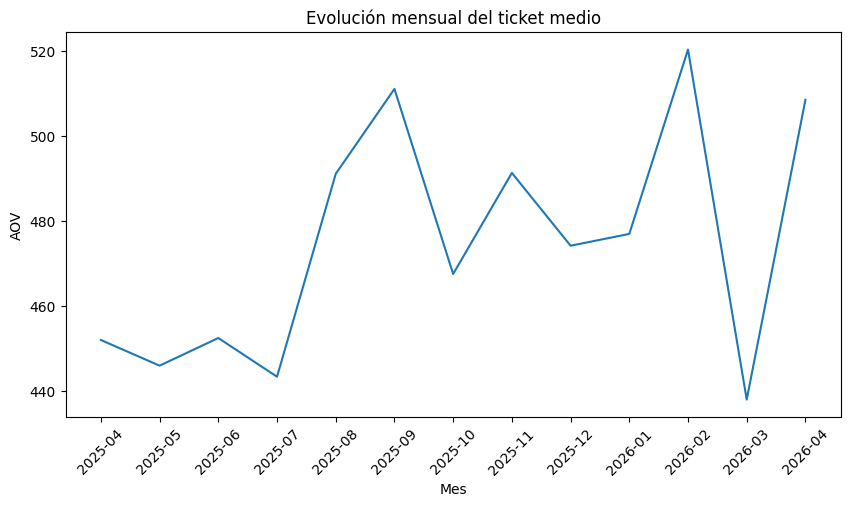

In [108]:
plt.figure(figsize=(10, 5))
plt.plot(aov_monthly["ORDER_DATE"], aov_monthly["AOV"])
plt.title("Evolución mensual del ticket medio")
plt.xlabel("Mes")
plt.ylabel("AOV")
plt.xticks(rotation=45)
plt.show()

### Interpretación
Observaciones sobre el AOV:
El ticket medio es sorprendentemente estable, oscilando entre €438 y €520 a lo largo de 12 meses completos — una variación de apenas el 18%, lo que indica que el mix de productos vendidos es consistente y no hay grandes distorsiones por promociones agresivas.
Hay una tendencia alcista suave en la segunda mitad del año: de julio a febrero el AOV sube de €443 a €520, lo que puede reflejar compras de mayor valor en temporada de otoño-invierno (Black Friday, Navidad). Esto valdría la pena cruzarlo con los datos de DIM_PRODUCTS para ver si hay categorías de mayor precio que ganan peso en esos meses.
Marzo 2026 rompe la tendencia con el AOV más bajo (€438), justo en el mes con mayor volumen de pedidos (91). Esto es un patrón clásico: cuando el volumen sube, el ticket baja, posiblemente por promociones o por un mix de productos más asequibles. Sería una hipótesis interesante de incluir en el análisis.
Abril 2026, con solo 7 pedidos, tiene un AOV de €508 — pero con una muestra tan pequeña no es estadísticamente significativo, así que conviene omitirlo de cualquier conclusión o marcarlo explícitamente como dato parcial.

## 7. Análisis de clientes

### Pregunta de negocio

¿Cuáles son los clientes con mayor valor para el negocio?

In [109]:
top_customers = (
    df_customer_metrics
    .sort_values("TOTAL_REVENUE", ascending=False)
    .head(10)
)

top_customers[
    [
        "CUSTOMER_ID",
        "TOTAL_ORDERS",
        "TOTAL_REVENUE",
        "AVG_ORDER_VALUE",
        "TOTAL_PROFIT"
    ]
]

,CUSTOMER_ID,TOTAL_ORDERS,TOTAL_REVENUE,AVG_ORDER_VALUE,TOTAL_PROFIT
255,289,4,4094.03,1023.507500,2108.82
198,427,6,3989.24,797.848000,1630.98
17,209,6,3468.34,693.668000,1532.56
80,122,8,3442.22,491.745714,1757.23
419,6,5,3200.39,800.097500,1288.81
271,15,4,3197.55,799.387500,1447.39
27,109,6,3095.68,515.946667,1539.39
66,304,3,3076.83,1025.610000,1286.55
246,395,3,3008.27,1002.756667,1355.39
358,74,4,2871.10,717.775000,1447.74


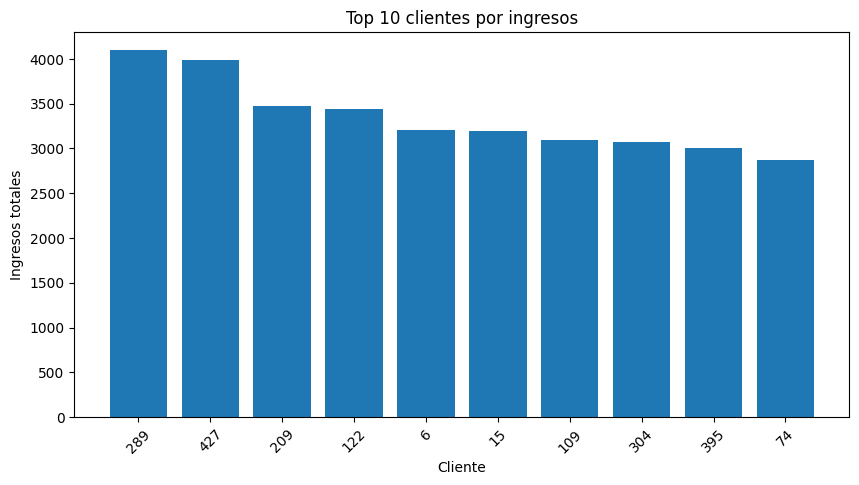

In [110]:
plt.figure(figsize=(10, 5))
plt.bar(top_customers["CUSTOMER_ID"].astype(str), top_customers["TOTAL_REVENUE"])
plt.title("Top 10 clientes por ingresos")
plt.xlabel("Cliente")
plt.ylabel("Ingresos totales")
plt.xticks(rotation=45)
plt.show()

### Interpretación

Hay dos perfiles claramente distintos dentro del top 10. Por un lado, clientes de alto ticket con pocos pedidos: el ID 289 (4 pedidos, AOV €1.024), ID 304 (3 pedidos, AOV €1.026) e ID 395 (3 pedidos, AOV €1.003). Por otro, clientes frecuentes con ticket más moderado: el ID 122 hace 8 pedidos con un AOV de solo €492, y el ID 427 hace 6 pedidos a €798. Son estrategias de compra completamente distintas.
El cliente 289 es el más valioso en todos los ejes: mayor revenue (€4.094), mayor beneficio (€2.109) y AOV elevado. Vale la pena perfilarlo más en detalle — categorías que compra, recencia — para entender qué lo hace tan rentable.
El cliente 122 es curioso: es el que más pedidos hace (8) pero tiene el AOV más bajo del grupo (€492), y aun así genera el segundo mayor beneficio (€1.757). Esto sugiere un margen por pedido sólido a pesar del ticket reducido — o bien compra productos con mejor margen.

## 8. Clientes activos e inactivos

### Pregunta de negocio

¿Cuántos clientes se consideran activos frente a inactivos?

In [111]:
reference_date = df_customer_metrics["LAST_PURCHASE_DATE"].max()
cutoff_date = reference_date - pd.Timedelta(days=90)

df_customer_metrics["CUSTOMER_STATUS"] = np.where(
    df_customer_metrics["LAST_PURCHASE_DATE"] >= cutoff_date,
    "Activo",
    "Inactivo"
)

customer_status = (
    df_customer_metrics["CUSTOMER_STATUS"]
    .value_counts()
    .reset_index()
)

customer_status.columns = ["CUSTOMER_STATUS", "TOTAL_CUSTOMERS"]

customer_status

,CUSTOMER_STATUS,TOTAL_CUSTOMERS
0,Inactivo,255
1,Activo,175


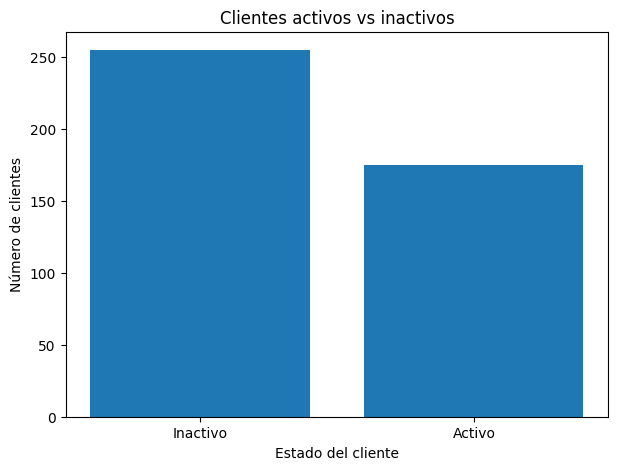

In [112]:
plt.figure(figsize=(7, 5))
plt.bar(customer_status["CUSTOMER_STATUS"], customer_status["TOTAL_CUSTOMERS"])
plt.title("Clientes activos vs inactivos")
plt.xlabel("Estado del cliente")
plt.ylabel("Número de clientes")
plt.show()

### Interpretación
El dato más importante aquí no es el número en sí, sino la pregunta que genera: ¿cómo se define "activo" en tu modelo de datos? Si la definición es "ha comprado en los últimos 90 días", un 59% de inactivos es una señal de alerta seria. Si es "ha comprado en los últimos 6 meses", es un resultado más normal para e-commerce con ciclos de compra largos. Vale la pena incluir esa definición explícitamente en el notebook — los revisores siempre la van a pedir.
El ratio de 1.46 inactivos por cada cliente activo es una métrica que puedes usar directamente como argumento de negocio: el mayor palanca de crecimiento no es adquirir clientes nuevos, sino reactivar los que ya compraron. Reactivar solo el 10% de los inactivos (26 clientes) llevaría la base activa al 46% sin coste de adquisición.

## 9. Distribución de pedidos por cliente

### Pregunta de negocio

¿Cómo se distribuye la frecuencia de compra entre los clientes?

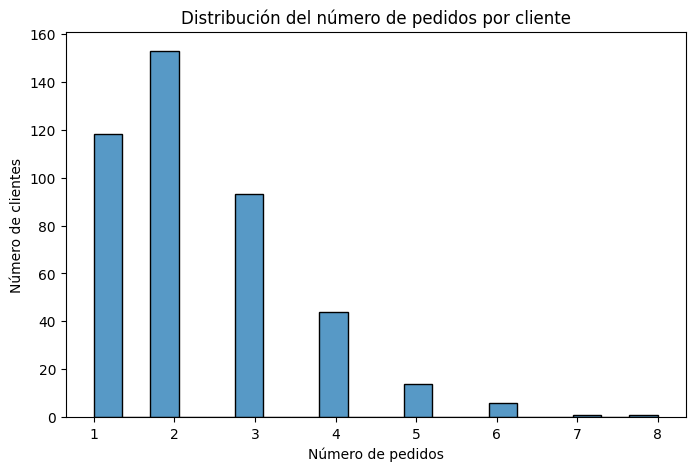

In [113]:
plt.figure(figsize=(8, 5))
sns.histplot(df_customer_metrics["TOTAL_ORDERS"], bins=20)
plt.title("Distribución del número de pedidos por cliente")
plt.xlabel("Número de pedidos")
plt.ylabel("Número de clientes")
plt.show()

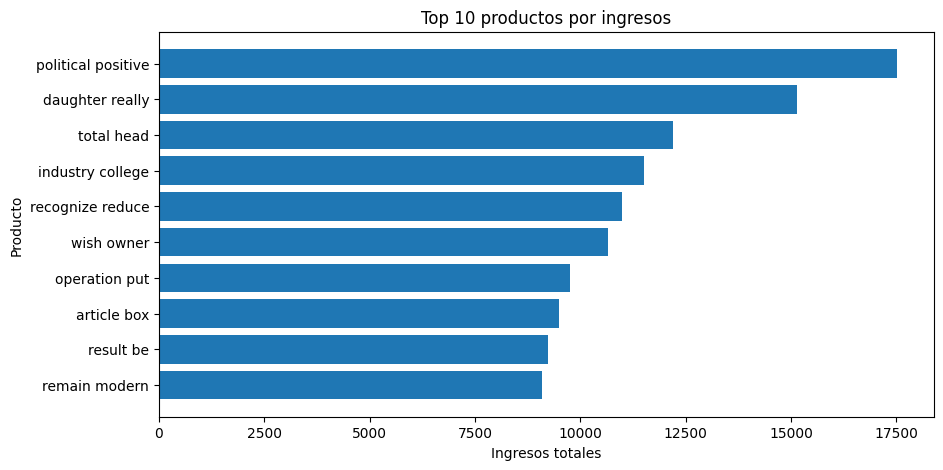

In [117]:
plt.figure(figsize=(10, 5))
plt.barh(top_products["PRODUCT_NAME"], top_products["TOTAL_REVENUE"])
plt.title("Top 10 productos por ingresos")
plt.xlabel("Ingresos totales")
plt.ylabel("Producto")
plt.gca().invert_yaxis()
plt.show()

## 11. Margen por categoría

### Pregunta de negocio

¿Qué categorías generan mayor margen de beneficio?

In [ ]:
margin_category = (
    df_items
    .groupby("CATEGORY")
    .agg(
        TOTAL_REVENUE=("VALOR_DA_LINHA", "sum"),
        TOTAL_PROFIT=("LUCRO", "sum")
    )
    .reset_index()
)

margin_category["PROFIT_MARGIN"] = (
    margin_category["TOTAL_PROFIT"] / margin_category["TOTAL_REVENUE"]
)

margin_category = margin_category.sort_values("PROFIT_MARGIN", ascending=False)

margin_category

,CATEGORY,TOTAL_REVENUE,TOTAL_PROFIT,PROFIT_MARGIN
4,roupa,92178.73,44686.56,0.484782
1,casa,88246.94,41158.32,0.466399
3,eletrónica,120330.76,54609.23,0.453826
2,desporto,89142.26,37780.36,0.423821
0,beleza,82078.49,33216.11,0.404687


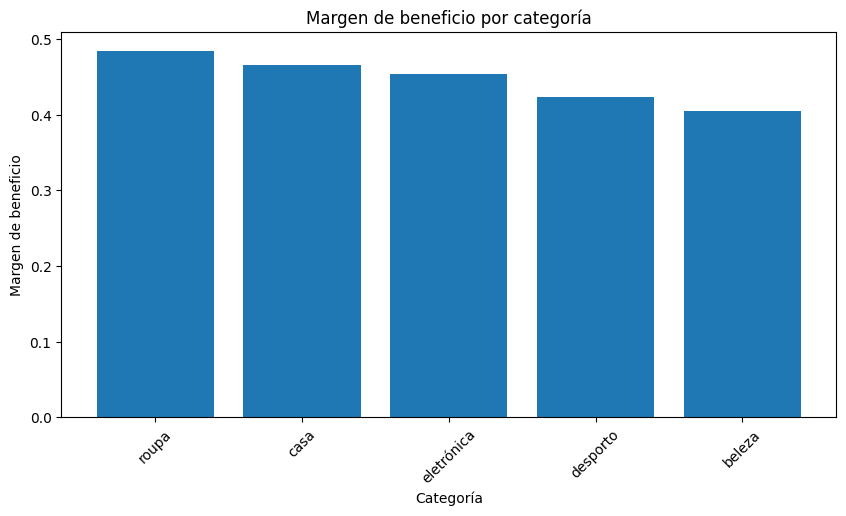

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(margin_category["CATEGORY"], margin_category["PROFIT_MARGIN"])
plt.title("Margen de beneficio por categoría")
plt.xlabel("Categoría")
plt.ylabel("Margen de beneficio")
plt.xticks(rotation=45)
plt.show()

El hallazgo más importante de esta sección es el diferencial de frecuencia: los clientes activos hacen de media 2.86 pedidos frente a 1.96 de los inactivos — un 46% más. Pero el impacto en revenue es aún mayor (+71%), lo que indica que los activos no solo compran más veces sino que también gastan más por pedido conforme se fidelizan.
El AOV casi no varía entre ambos grupos (€473 vs €462), lo que confirma que el driver principal de valor no es el ticket unitario sino la repetición de compra. Esto es una conclusión de negocio directa: las acciones de retención tienen más retorno que las de upselling.

## 12. Relación entre precio y cantidad vendida

### Pregunta de negocio

¿Existe relación entre el precio de los productos y la cantidad vendida?

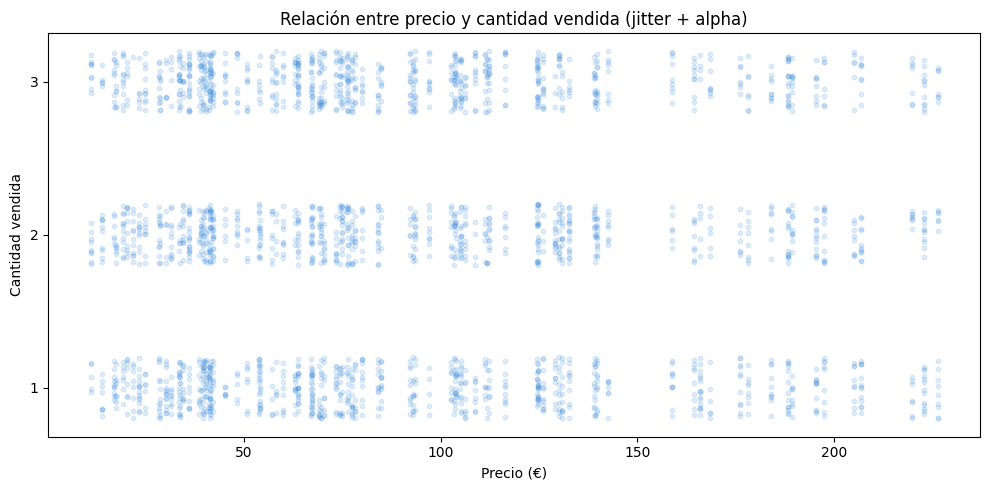

In [120]:
import numpy as np

jitter_y = df_items["QUANTITY"] + np.random.uniform(-0.2, 0.2, len(df_items))

plt.figure(figsize=(10, 5))
plt.scatter(
    df_items["PRICE"],
    jitter_y,
    alpha=0.15,
    s=10,
    color="#378ADD"
)
plt.yticks([1, 2, 3])
plt.xlabel("Precio (€)")
plt.ylabel("Cantidad vendida")
plt.title("Relación entre precio y cantidad vendida (jitter + alpha)")
plt.tight_layout()
plt.show()

In [121]:
correlation_price_quantity = df_items[["PRICE", "QUANTITY"]].corr()
correlation_price_quantity

,PRICE,QUANTITY
PRICE,1.000000,-0.018003
QUANTITY,-0.018003,1.000000


In [122]:
# Distribución real de cantidades
df_items["QUANTITY"].value_counts(normalize=True).sort_index()

# Precio medio por cantidad — ¿compran más unidades de productos baratos?
df_items.groupby("QUANTITY")["PRICE"].mean()

QUANTITY
1    93.759965
2    92.829806
3    91.285518
Name: PRICE, dtype: float64

La correlación de Pearson entre precio y cantidad es de −0.018, prácticamente nula, lo que descarta cualquier relación lineal entre ambas variables. Sin embargo, antes de concluir, es importante señalar una limitación metodológica: la cantidad vendida toma únicamente valores discretos (1, 2 y 3 unidades), lo que hace que Pearson sea una métrica poco adecuada para este par de variables, ya que asume continuidad en ambas dimensiones. 
La diferencia entre los extremos es de apenas €2.47 — un 2.6% de variación sobre una base de ~€93, sin ninguna relevancia económica ni estadística. Los clientes que compran 3 unidades pagan prácticamente lo mismo por unidad que los que compran 1.
Para visualizar correctamente esta distribución, se aplicó jitter vertical y transparencia al scatter plot original, técnica estándar para variables discretas. El resultado reveló dos fenómenos distintos que el gráfico original mezclaba visualmente: la proporción entre cantidades 1, 2 y 3 se mantiene constante a lo largo de todo el rango de precios, pero el volumen total de transacciones cae a partir de €160 — no porque los productos caros se compren en menor cantidad, sino porque el catálogo tiene menos productos en ese tramo de precio.

## 13. Cancelaciones

### Pregunta de negocio

¿Cuál es la evolución de las cancelaciones y cuál es el impacto económico?

In [ ]:
cancel_monthly = (
    df_cancel_metrics
    .groupby(df_cancel_metrics["ORDER_DATE"].dt.to_period("M"))
    .agg(
        TOTAL_CANCELLED_ORDERS=("TOTAL_CANCELLED_ORDERS", "sum"),
        LOST_REVENUE=("LOST_REVENUE", "sum"),
        LOST_PROFIT=("LOST_PROFIT", "sum")
    )
    .reset_index()
)

cancel_monthly["ORDER_DATE"] = cancel_monthly["ORDER_DATE"].astype(str)

cancel_monthly

,ORDER_DATE,TOTAL_CANCELLED_ORDERS,LOST_REVENUE,LOST_PROFIT
0,2025-04,13,5243.53,2342.73
1,2025-05,14,5181.15,2235.74
2,2025-06,11,5475.24,2500.60
3,2025-07,13,5407.22,2209.19
4,2025-08,18,10885.82,5230.36
5,2025-09,14,6111.83,2774.31
6,2025-10,12,4929.09,2154.79
7,2025-11,18,10021.57,4013.44
8,2025-12,8,4498.30,2041.05
9,2026-01,19,9221.29,4318.25


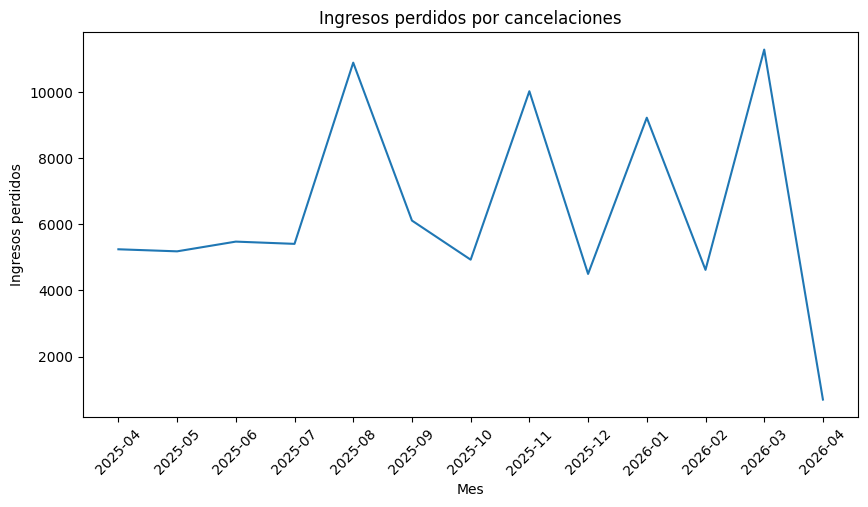

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(cancel_monthly["ORDER_DATE"], cancel_monthly["LOST_REVENUE"])
plt.title("Ingresos perdidos por cancelaciones")
plt.xlabel("Mes")
plt.ylabel("Ingresos perdidos")
plt.xticks(rotation=45)
plt.show()

In [127]:
# Agregar cancelaciones por mes
cancel_monthly = (
    df_cancel_metrics
    .groupby("ORDER_DATE")
    .agg(TOTAL_CANCELLED_ORDERS=("TOTAL_CANCELLED_ORDERS", "sum"),
         LOST_REVENUE=("LOST_REVENUE", "sum"),
         LOST_PROFIT=("LOST_PROFIT", "sum"))
    .reset_index()
)

cancel_monthly["ORDER_DATE"] = pd.to_datetime(cancel_monthly["ORDER_DATE"]).dt.to_period("M").astype(str)

# Merge con revenue_monthly
cancel_vs_orders = revenue_monthly.merge(
    cancel_monthly,
    on="ORDER_DATE",
    how="left"
)

cancel_vs_orders["CANCEL_RATE"] = (
    cancel_vs_orders["TOTAL_CANCELLED_ORDERS"] / cancel_vs_orders["TOTAL_ORDERS"]
).round(3)

cancel_vs_orders[["ORDER_DATE", "TOTAL_ORDERS", "TOTAL_CANCELLED_ORDERS", "CANCEL_RATE"]]

,ORDER_DATE,TOTAL_ORDERS,TOTAL_CANCELLED_ORDERS,CANCEL_RATE
0,2025-04,74,13,0.176
1,2025-05,91,14,0.154
2,2025-06,65,11,0.169
3,2025-07,80,13,0.162
4,2025-08,88,18,0.205
5,2025-09,78,14,0.179
6,2025-10,96,12,0.125
7,2025-11,84,18,0.214
8,2025-12,82,8,0.098
9,2026-01,87,19,0.218


In [133]:
cancel_by_category = (
    df_cancellations
    .merge(df_items[["ORDER_ID", "CATEGORY"]], left_on="order_id", right_on="ORDER_ID", how="left")
    .groupby("CATEGORY")
    .size()
    .reset_index(name="TOTAL_CANCELLATIONS")
    .sort_values("TOTAL_CANCELLATIONS", ascending=False)
)
cancel_by_category

,CATEGORY,TOTAL_CANCELLATIONS
3,eletrónica,122
0,beleza,96
2,desporto,80
4,roupa,79
1,casa,66


In [134]:
# ¿Cuáles son los motivos de cancelación más frecuentes?
cancel_reasons = (
    df_cancellations["cancel_reason"]
    .value_counts()
    .head(10)
    .reset_index()
)
cancel_reasons.columns = ["REASON", "COUNT"]
cancel_reasons

,REASON,COUNT
0,Bed teach mind alone traditional.,1
1,Against eye quality.,1
2,Star deal ability film say.,1
3,Loss water necessary.,1
4,Against green administration onto.,1
5,Group relate lay behavior.,1
6,Would necessary continue less.,1
7,Quality leave record.,1
8,Identify card list care.,1
9,Argue wind rise.,1


A lo largo de los 12 meses analizados se registraron 171 pedidos cancelados, lo que representa una tasa media de cancelación del 17.1% — significativamente por encima del benchmark habitual del e-commerce, situado entre el 5% y el 10%. El impacto económico acumulado asciende a €83,876 en revenue perdido y €37,162 en beneficio no realizado, con un margen de cancelación del 44.3%, prácticamente idéntico al margen general del negocio, lo que indica que las cancelaciones afectan al mix completo de productos sin concentrarse en segmentos de mayor o menor rentabilidad.
El análisis temporal revela que la tasa de cancelación no correlaciona con el volumen de pedidos: octubre, el mes con más pedidos (96), registra una de las tasas más bajas (12.5%), mientras que enero y marzo, con volúmenes similares al promedio, alcanzan tasas del 21.8% y 22.0% respectivamente. Esta ausencia de patrón descarta un problema de capacidad operacional y apunta a una causa estructural — posiblemente relacionada con expectativas del producto, política de devoluciones o experiencia post-compra.
Por categoría, las cancelaciones están distribuidas de forma relativamente uniforme. Electrónica lidera en términos absolutos con 122 cancelaciones, pero también es la categoría de mayor revenue (€120,330), por lo que su peso relativo en cancelaciones (27.5%) es solo ligeramente superior a su peso en revenue (25.2%). Casa es la categoría más sana del negocio: representa el 18.5% del revenue pero solo el 14.9% de las cancelaciones.

## 14. Análisis de churn

### Pregunta de negocio

¿Qué diferencia a los clientes activos de los clientes inactivos?

In [ ]:
df_customer_metrics["CHURN_FLAG"] = np.where(
    df_customer_metrics["CUSTOMER_STATUS"] == "Inactivo",
    1,
    0
)

churn_summary = (
    df_customer_metrics
    .groupby("CHURN_FLAG")
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_ID", "count"),
        AVG_TOTAL_ORDERS=("TOTAL_ORDERS", "mean"),
        AVG_REVENUE=("TOTAL_REVENUE", "mean"),
        AVG_ORDER_VALUE=("AVG_ORDER_VALUE", "mean"),
        AVG_PROFIT=("TOTAL_PROFIT", "mean")
    )
    .reset_index()
)

churn_summary

,CHURN_FLAG,TOTAL_CUSTOMERS,AVG_TOTAL_ORDERS,AVG_REVENUE,AVG_ORDER_VALUE,AVG_PROFIT
0,0,175,2.857143,1198.226400,472.585899,535.963657
1,1,255,1.960784,700.825294,462.329889,314.490863


Ao longo do período analisado, observa-se uma diferença clara entre clientes ativos e inativos, tanto em comportamento de compra como em impacto financeiro no negócio.

Os clientes ativos (CHURN_FLAG = 0) apresentam, em média, 2.86 pedidos por cliente, enquanto os clientes inativos (CHURN_FLAG = 1) ficam-se por 1.96 pedidos. Isto representa uma redução de cerca de 31% na frequência de compra, o que já indica um sinal forte de disengagement antes do churn acontecer.

Em termos de receita, a diferença é ainda mais expressiva. Clientes ativos geram, em média, €1,198 por cliente, enquanto clientes inativos geram apenas €701. Trata-se de uma quebra de aproximadamente 41%, o que demonstra que o churn não é apenas uma perda de volume, mas sobretudo de valor.

Curiosamente, o valor médio por pedido (AOV) mantém-se relativamente estável entre os dois grupos - €472 para ativos vs €462 para inativos. Isto indica que o problema não está no ticket médio, mas sim na frequência de compra. Ou seja, clientes que abandonam não compram menos por pedido, compram menos vezes.

No lucro médio, a diferença acompanha a tendência da receita. Clientes ativos geram €536 de lucro médio, enquanto clientes inativos ficam-se pelos €314, uma redução de cerca de 41%. A consistência entre receita e lucro sugere que o churn afeta o negócio de forma proporcional, sem enviesamento para clientes mais ou menos rentáveis.



## 15. Estacionalidad de ventas

### Pregunta de negocio

¿Existen patrones de venta por día de la semana o por mes?

In [ ]:
df_daily_sales["WEEKDAY"] = df_daily_sales["ORDER_DATE"].dt.day_name()
df_daily_sales["MONTH"] = df_daily_sales["ORDER_DATE"].dt.month

seasonality = df_daily_sales.pivot_table(
    values="TOTAL_REVENUE",
    index="WEEKDAY",
    columns="MONTH",
    aggfunc="sum"
)

seasonality

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
WEEKDAY,,,,,,,,,,,,
Friday,2666.05,4699.72,4561.39,3868.29,7478.27,2611.05,3054.38,6105.56,4742.97,7065.22,3386.39,3801.26
Monday,4789.53,1846.35,4493.32,3035.08,6132.59,2790.01,3420.39,2063.93,6368.37,5167.48,5887.11,7434.77
Saturday,3330.07,5380.96,3692.91,5401.73,6151.09,3644.13,2561.80,3893.63,6238.94,8689.65,5122.95,2765.45
Sunday,3924.22,4795.31,3646.18,4464.69,1817.45,4398.00,3734.38,6113.60,4544.69,2233.71,4488.67,3563.94
Thursday,5993.39,7010.45,2419.51,6981.28,5358.71,2649.25,3242.14,7069.64,5278.87,5400.74,3767.40,7176.51
Tuesday,7150.88,3370.64,5417.08,2259.86,4160.25,4380.41,6660.45,2469.30,3806.92,6308.93,3591.34,4018.26
Wednesday,4417.71,8337.12,4344.01,5052.18,4301.59,3460.87,7386.97,4611.70,2768.08,5085.58,5001.93,5622.49


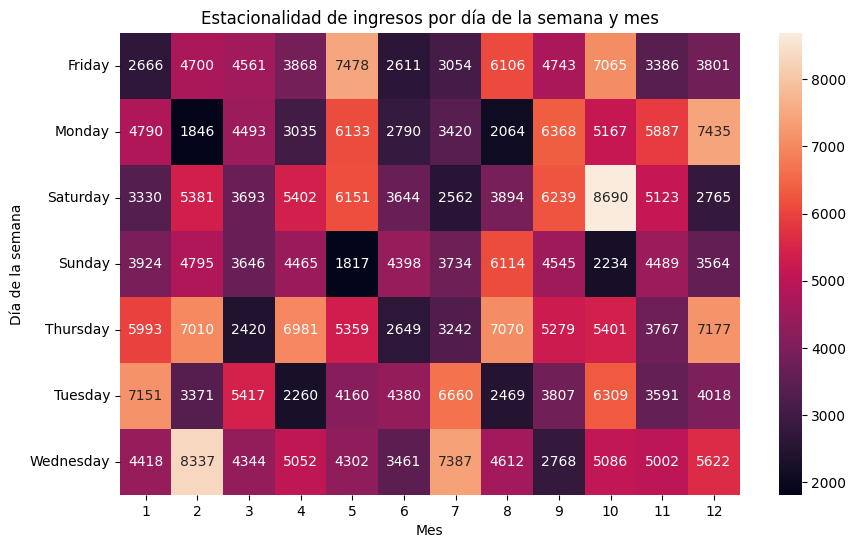

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(seasonality, annot=True, fmt=".0f")
plt.title("Estacionalidad de ingresos por día de la semana y mes")
plt.xlabel("Mes")
plt.ylabel("Día de la semana")
plt.show()

Ao longo dos 12 meses analisados, não se observa um padrão linear ou totalmente previsível de vendas por mês, mas existem sinais claros de sazonalidade quando se cruza o dia da semana com determinados períodos do ano.

Em termos mensais, não há um único mês consistentemente dominante, o que indica ausência de uma sazonalidade clássica forte. Ainda assim, alguns picos destacam-se, como outubro, onde se registam vários dos valores mais elevados, incluindo o máximo absoluto aos sábados (€8,689). Maio, julho e dezembro também apresentam níveis elevados em vários dias, sugerindo períodos de maior atividade comercial possivelmente associados a campanhas, sazonalidade de consumo ou momentos económicos específicos.

Ao nível dos dias da semana, o comportamento é mais consistente. Quintas-feiras e sextas-feiras tendem a concentrar valores elevados de receita em vários meses, o que indica um padrão de compra mais forte no final da semana útil. Sábados também apresentam picos relevantes, especialmente em meses de maior volume, reforçando a ideia de que o fim de semana impulsiona as vendas.

Por outro lado, domingos mostram maior volatilidade e incluem alguns dos valores mais baixos do dataset, como maio (€1,817) e outubro (€2,233), o que pode indicar menor propensão de compra nesse dia ou limitações operacionais.

Segundas e terças-feiras apresentam um comportamento intermédio, mas com alguma irregularidade. Existem picos pontuais como terça-feira em janeiro (€7,150) ou segunda-feira em dezembro (€7,434), mas sem consistência ao longo do ano.

Um ponto relevante é a variabilidade intra-semana dentro do mesmo mês. Por exemplo, em fevereiro, quarta-feira atinge €8,337, enquanto segunda-feira cai para €1,846. Esta dispersão sugere que fatores adicionais - como campanhas específicas, promoções ou comportamento do consumidor - têm mais impacto do que apenas o calendário.

## 16. Crecimiento de ingresos

### Pregunta de negocio

¿Los ingresos están creciendo a lo largo del tiempo?

In [ ]:
daily_growth = df_daily_sales.sort_values("ORDER_DATE").copy()

daily_growth["PREVIOUS_REVENUE"] = daily_growth["TOTAL_REVENUE"].shift(1)

daily_growth["REVENUE_GROWTH_RATE"] = (
    (daily_growth["TOTAL_REVENUE"] - daily_growth["PREVIOUS_REVENUE"])
    / daily_growth["PREVIOUS_REVENUE"]
)

daily_growth.head()

,ORDER_DATE,TOTAL_ORDERS,TOTAL_REVENUE,TOTAL_COST,TOTAL_PROFIT,WEEKDAY,MONTH,PREVIOUS_REVENUE,REVENUE_GROWTH_RATE
0,2025-04-02,1,639.48,375.32,264.16,Wednesday,4,NaN,NaN
1,2025-04-04,2,875.51,427.99,447.52,Friday,4,639.48,0.369097
2,2025-04-05,4,2749.93,1632.66,1117.27,Saturday,4,875.51,2.140946
3,2025-04-06,1,821.28,388.63,432.65,Sunday,4,2749.93,-0.701345
4,2025-04-07,2,720.32,452.26,268.06,Monday,4,821.28,-0.122930


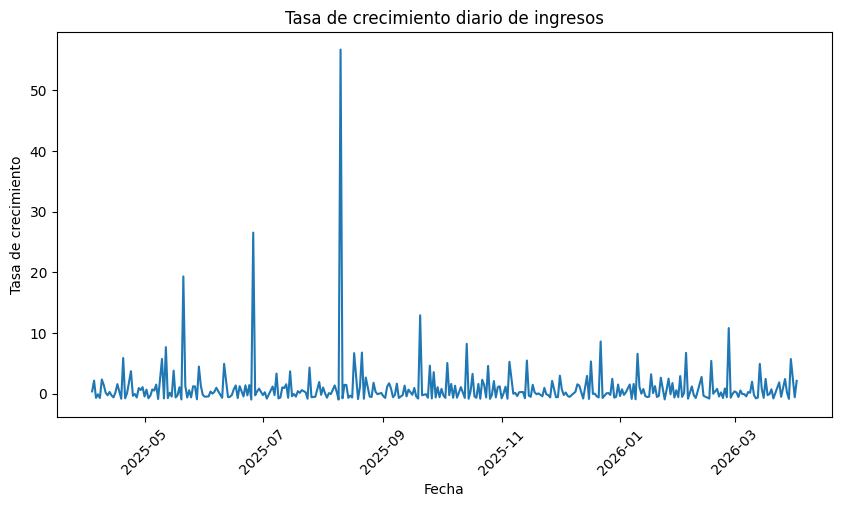

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(daily_growth["ORDER_DATE"], daily_growth["REVENUE_GROWTH_RATE"])
plt.title("Tasa de crecimiento diario de ingresos")
plt.xlabel("Fecha")
plt.ylabel("Tasa de crecimiento")
plt.xticks(rotation=45)
plt.show()

Ao longo do período analisado, os ingresos não apresentam uma tendência de crescimento sustentado, mas sim um comportamento altamente volátil, com oscilações frequentes ao longo do tempo.

A maioria das variações diárias de receita concentra-se em torno de valores baixos, próximos de 0% a 5%, o que indica estabilidade relativa no dia a dia. No entanto, esta estabilidade é constantemente interrompida por picos abruptos de crescimento, alguns superiores a 20% e um caso extremo acima de 50%, evidenciando eventos pontuais de forte aumento de receita.

Estes picos não seguem um padrão temporal claro nem uma tendência progressiva, o que descarta um crescimento orgânico contínuo. Em vez disso, sugerem que os ingresos são impulsionados por fatores específicos e isolados, como campanhas promocionais, grandes encomendas ou sazonalidade de curto prazo.

Por outro lado, também se observam quedas acentuadas após esses picos, como no exemplo de abril, onde um crescimento de 214% num dia é seguido por uma quebra de -70% no dia seguinte. Este comportamento reforça a ideia de que o crescimento não é acumulativo, mas sim episódico.

A ausência de uma trajetória ascendente consistente ao longo do tempo indica que o negócio não está a escalar de forma previsível. Em termos práticos, isto significa que a

## 17. Conclusiones del análisis

Este análisis permitió evaluar el rendimiento comercial de un e-commerce a partir de datos almacenados en Snowflake.
Desde una perspectiva de negocio, el análisis cubre de forma completa los principales drivers de performance: evolución de ingresos y pedidos, ticket medio, comportamiento de clientes, rendimiento de productos, rentabilidad, cancelaciones, churn y patrones de demanda. Esto permite soportar decisiones estratégicas en ventas, retención, pricing y optimización del catálogo.
Desde una perspectiva técnica, el proyecto demuestra capacidad para integrar Python con un Data Warehouse, procesar datos con Pandas, construir KPIs relevantes y traducir resultados analíticos en insights accionables.
A nivel de ingresos y pedidos, no se observa un crecimiento sostenido en el tiempo. El comportamiento es volátil, con picos puntuales que no siguen una tendencia estructural. Esto indica que el negocio depende más de eventos específicos - como campañas o promociones - que de una base recurrente sólida.
El ticket medio (AOV) se mantiene notablemente estable a lo largo del periodo, con una variación limitada. Esto sugiere consistencia en el mix de productos vendidos. Sin embargo, existe una relación inversa clara entre volumen y ticket: cuando aumentan los pedidos, el valor medio baja, lo que apunta a estrategias comerciales basadas en volumen.
En el análisis de clientes, se identifican dos perfiles de alto valor - clientes de alto ticket con baja frecuencia y clientes recurrentes con ticket moderado. Ambos contribuyen de forma distinta al negocio. El cliente más valioso combina alto gasto y alta rentabilidad, lo que lo convierte en un perfil clave para replicar mediante segmentación.
La proporción de clientes inactivos es elevada, con un ratio de 1.46 inactivos por cada activo. Independientemente de la definición exacta de “activo”, este indicador revela una oportunidad clara: el mayor potencial de crecimiento está en la reactivación, no en la adquisición.
El análisis de churn refuerza esta conclusión. La diferencia entre clientes activos e inactivos no está en el valor por pedido, sino en la frecuencia de compra. El churn es, esencialmente, una pérdida de recurrencia. Esto orienta las estrategias hacia engagement, fidelización y experiencia post-compra.
En cuanto a productos y categorías, el rendimiento es relativamente equilibrado. No se detectan distorsiones fuertes en volumen o comportamiento de compra por precio. La relación entre precio y cantidad es prácticamente nula, lo que indica que la demanda no es sensible al precio dentro del rango analizado.
El margen de beneficio se mantiene consistente entre categorías y también en pedidos cancelados, lo que indica que la rentabilidad está distribuida de forma homogénea en el catálogo.
Las cancelaciones representan uno de los principales puntos críticos del negocio. La tasa del 17.1% está muy por encima del estándar del sector y genera un impacto económico relevante tanto en ingresos como en beneficio. La ausencia de correlación con el volumen de pedidos sugiere un problema estructural más que operacional.
A nivel de categorías, las cancelaciones están distribuidas de forma relativamente uniforme. No existe una categoría claramente problemática, aunque electrónica presenta un peso ligeramente superior debido a su volumen.
El análisis de estacionalidad muestra un patrón semanal más consistente que el mensual. Las ventas tienden a concentrarse entre jueves y sábado, mientras que los domingos presentan menor rendimiento. A nivel mensual, los picos parecen depender de eventos concretos más que de una estacionalidad fija.
En síntesis, el negocio presenta tres características clave: estabilidad en el ticket medio, alta dependencia de eventos puntuales para generar ingresos y una base de clientes con margen significativo de mejora en retención. Las principales palancas de crecimiento pasan por aumentar la recurrencia, reducir cancelaciones y estabilizar la generación de ingresos a lo largo del tiempo.